# NN from Scratch - Part II
In this notebook, we further explore adaptive learning rate and stochastic gradient descent (SGD).

In [1]:
from NN_functions import *
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import tensorflow as tf 
import matplotlib.pyplot as plt

`?function_name` can quickly give us the information of this function.

In [3]:
?simple_NN

Signature: simple_NN(X, y, seed=2, lr=0.1, hidden_size=5, max_iter=30, **kwargs)
Docstring:
X, y should be numpy arrays
W1_init: optional argument for initialized weight
W2_init: optional argument for initialized weight
File:      ~/Documents/GIT/MTDS/notebooks/NN_functions.py
Type:      function

## A comment on `**kwargs`
`**kwargs` stands for "keyword arguments". It should be placed at the end of arguments and provides optional arguments in the format of dictionary.

Below is a quick example

In [2]:
def test_kwargs(**kwargs):
    name_default = "John"

    # if there is no keyword "name" in kwargs, then use name_default
    name = kwargs.get('name', name_default)
    return name

In [4]:
test_kwargs()

'John'

In [5]:
test_kwargs(name = 'Mike')

'Mike'

## Back to the housing data

In [4]:
# data prep
ames = pd.read_csv("../data/ames.csv")
ames_num = ames.select_dtypes(exclude=['object'])
yh = ames['Sale_Price']
Xh = ames_num.iloc[:,:-3] # selecting all but the last 3 columns
X_train, X_test, y_train, y_test = train_test_split(Xh, yh, test_size = 0.25, random_state = 45)
X_train_n = X_train.to_numpy()
y_train_n = y_train.to_numpy()
X_test_n = X_test.to_numpy()
y_test_n = y_test.to_numpy()

In [5]:
# hidden layer size
p1 = 5

## 1. Feed `simple_NN()` with trained weights

In practice, trained weights are what's precious and will do the prediction job for new data. If our **initialized weights** are already somewhat trained, it means we can at least use fewer iterations.

Below, we have split these 30K iterations into 3 portions. We feed the previously trained weights into the next portion.

In [6]:
# 3e4
W1_1, W2_1, J_1, u2_1 = simple_NN(X_train_n, y_train_n, hidden_size = p1, seed = 3, lr = 0.5e-13, max_iter = int(1e4))
# now that J_MSE is properly defined, it equals the square of RMSE
print(J_1**0.5)
print(root_mean_squared_error(u2_1, y_train_n))

40472.64581352626
40472.64581352626


In [7]:
W1_2, W2_2, J_2, u2_2 = simple_NN(X_train_n, y_train_n, hidden_size = p1, seed = 3, lr = 0.5e-13, max_iter = int(1e4),
                                 W1_init = W1_1,
                                 W2_init = W2_1)
print(J_2**0.5)

40076.11782201403


In [8]:
W1_3, W2_3, J_3, u2_3 = simple_NN(X_train_n, y_train_n, hidden_size = p1, seed = 3, lr = 0.5e-13, max_iter = int(1e4),
                                 W1_init = W1_2,
                                 W2_init = W2_2)
print(J_3**0.5)

39570.033623801166


## Result from linear reg

In [9]:
lm_h = LinearRegression().fit(X_train,y_train)
# use a data frame for output
results = pd.DataFrame({'training_RMSE':[],
                        'testing_RMSE':[]})
results.loc['linear',:] = [root_mean_squared_error(lm_h.predict(X_train), y_train.to_numpy()),
                           root_mean_squared_error(lm_h.predict(X_test), y_test.to_numpy())]
results

,training_RMSE,testing_RMSE
linear,35387.072625,39607.455308


## 2. Adjusting learning rate
We know that the learning rate affects the training significantly, so we will go through some common optimizaiton techniques for having better (adaptive) learning rates.

In [54]:
def simple_NN_l1(X, y, seed = 2, hidden_size = 5, max_iter = 30, lr = 1e-13, **kwargs):
    '''
    X, y should be numpy arrays
    W1_init: optional argument for initialized weight
    W2_init: optional argument for initialized weight
    gd: optional argument for gradient descent method. Choices are 
        'regular'
        'momentum': optional arg "mu", default is 0.95
        'AdaGrad':
        'RMSprop':
    '''
    n, p = X.shape
    # reshape y to a column
    y = y.reshape([-1, 1])

    # size (number of nodes) of hidden layer
    p1 = hidden_size
    
    # random initialization if initial weights not provided
    np.random.seed(seed)
    w_scale = np.sqrt(6/(p+1))
    W1_rand = np.random.rand(p, p1) * w_scale 
    W2_rand = np.random.rand(p1, 1) * w_scale

    W1 = kwargs.get('W1_init', W1_rand)
    W2 = kwargs.get('W2_init', W2_rand)

    # pick which gradient descent method
    # regular method if not provided
    gd = kwargs.get('gd', 'regular')

    # initialization and hyperparameter for advanced gradient descent methods
    if gd == 'momentum':
        v1 = 0
        v2 = 0
        mu = kwargs.get('mu', 0.95)
    elif gd == 'AdaGrad':
        r1 = 0
        r2 = 0
    elif gd == 'RMSProp':
        rho = kwargs.get('rho', 0.9)
        r1 = 0
        r2 = 0
        
        
    for i in range(max_iter):
        # forward propargation (usually should be a for loop, iterate over how many hidden layers there are)
        u1, h, u2 = forward_prop(X, W1, W2) # u2 is supposed to be approx y
    
        # compute cost
        J = J_MSE(u2, y)
    
        # backward propagation for computing gradient (usually a for loop iterate over # of hidden layers)
        dW1, dW2 = backward_prop(X, y, u1, h, u2, W1, W2)
        
        # gradient descent with momentum
        if gd == 'momentum':
            v1 = mu*v1 - lr*dW1
            v2 = mu*v2 - lr*dW2
            W1 = W1 + v1
            W2 = W2 + v2
        elif gd == 'AdaGrad':
            r1 = r1 + dW1**2
            r2 = r2 + dW2**2
            W1 = W1 - lr/(1e-7 + r1**0.5)*dW1
            W2 = W2 - lr/(1e-7 + r2**0.5)*dW2
        elif gd == 'RMSprop':
            r1 = rho*r1 + (1-rho) * dW1**2
            r2 = rho*r2 + (1-rho) * dW2**2
            W1 = W1 - lr/((1e-6 + r1)**0.5)*dW1
            W2 = W2 - lr/((1e-6 + r2)**0.5)*dW2

        # if alpha = 0, then this is the same as simple_NN()        
    
    return W1, W2, J, u2

In [11]:
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n, y_train_n, hidden_size = p1, seed = 3, mu = 0.95, lr = 1e-13, max_iter = int(4e4),   
                                     gd = 'momentum',
                                 )
f"training error for using momentum is {J_m**0.5:.2f}"

'training error for using momentum is 30974.31'

In [12]:
# test error?
y_pred = simple_NN_pred(X_test_n, W1_m, W2_m)
f"testing error for using momentum is {root_mean_squared_error(y_pred, y_test):.2f}"

'testing error for using momentum is 34858.53'

In [13]:
results.loc['simple_NN_momentum',:] = [J_m**0.5,
                                       root_mean_squared_error(y_pred, y_test)]
results

,training_RMSE,testing_RMSE
linear,35387.072625,39607.455308
simple_NN_momentum,30974.312249,34858.528183


In [14]:
W1_a, W2_a, J_a, u2_a = simple_NN_l1(X_train_n, y_train_n, hidden_size = p1, seed = 3, lr = 1e0, max_iter = int(4.5e4),   
                                     gd = 'AdaGrad',
                                 )
f"training error for using AdaGrad is {J_a**0.5:.2f}"

'training error for using AdaGrad is 33601.04'

In [15]:
results.loc['simple_NN_AdaGrad',:] = [J_a**0.5,
                                       root_mean_squared_error(simple_NN_pred(X_test_n, W1_a, W2_a), y_test)]
results

,training_RMSE,testing_RMSE
linear,35387.072625,39607.455308
simple_NN_momentum,30974.312249,34858.528183
simple_NN_AdaGrad,33601.042640,41646.631354


In [32]:
W1_r, W2_r, J_r, u2_r = simple_NN_l1(X_train_n, y_train_n, hidden_size = p1, seed = 3, rho = 0.9, lr = 1e-2, max_iter = int(4.5e4),   
                                     gd = 'RMSprop',
                                 )
f"training error for using AdaGrad is {J_r**0.5:.2f}"

'training error for using AdaGrad is 34318.58'

In [33]:
results.loc['simple_NN_RMSProp',:] = [J_r**0.5,
                                       root_mean_squared_error(simple_NN_pred(X_test_n, W1_r, W2_r), y_test)]
results

,training_RMSE,testing_RMSE
linear,35387.072625,39607.455308
simple_NN_momentum,30974.312249,34858.528183
simple_NN_AdaGrad,33601.042640,41646.631354
simple_NN_RMSProp,34318.583809,42016.666005


## Stochastic Gradient Descent (SGD)
At each iteration of the gradient descent, the gradient will be **approximated** from only a minibatch of training data.

In [17]:
X_train.shape

(2197, 31)

We will let the batchsize be 200. The training data will be split into $2197/200\approx 11$ batches.

In [18]:
bs = 200 # batch size

In [19]:
# update parameters using first batch
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n[:bs,:], y_train_n[:bs], hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-12, max_iter = 100,                                 
                                 )
print(J_m**0.5)

44733.873546237104


In [20]:
# update parameters using 2nd batch
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n[bs:(2*bs),:], y_train_n[bs:(2*bs)], hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-12, max_iter = 100,                                 
                                    W1_init = W1_m,
                                    W2_init = W2_m)
print(J_m**0.5)

37320.134266197616


In [21]:
# update parameters using 3rd batch
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n[(2*bs):(3*bs),:], y_train_n[(2*bs):(3*bs)], hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-12, max_iter = 100,                                 
                                    W1_init = W1_m,
                                    W2_init = W2_m)
print(J_m**0.5)

44024.492377805305


In [22]:
# update parameters using 4th batch
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n[(3*bs):(4*bs),:], y_train_n[(3*bs):(4*bs)], hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-12, max_iter = 100,                                 
                                    W1_init = W1_m,
                                    W2_init = W2_m)
print(J_m**0.5)

34592.11024073718


In [23]:
# update parameters using 5th batch
W1_m, W2_m, J_m, u2_m = simple_NN_l1(X_train_n[(4*bs):(5*bs),:], y_train_n[(4*bs):(5*bs)], hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-12, max_iter = 100,                                 
                                    W1_init = W1_m,
                                    W2_init = W2_m)
print(J_m**0.5)

36338.14309988089


...

We can keep going until we go through all 11 batches. In practice, we will make 2 modifications:

- Each batch is drawn randomly from the whole traning set. This is usually done by randomly shuffling the whole training set first.
- Only **one** iteration is run for a minibatch.

We will write a function with these two modifications in mind.

In [95]:
def simple_NN_SGD(X, y, seed = 2, hidden_size = 5, bs = 200, n_epoch = 30, alpha = 0.5, lr = 1e-13, **kwargs):
    '''
    X, y should be numpy arrays
    W1_init: optional argument for initialized weight
    W2_init: optional argument for initialized weight
    '''
    n, p = X.shape
    # reshape y to a column
    y = y.reshape([-1, 1])

    # size (number of nodes) of hidden layer
    p1 = hidden_size
    
    # random initialization if initial weights not provided
    np.random.seed(seed)
    w_scale = np.sqrt(6/(p+1))
    W1_rand = np.random.rand(p, p1) * w_scale 
    W2_rand = np.random.rand(p1, 1) * w_scale

    W1 = kwargs.get('W1_init', W1_rand)
    W2 = kwargs.get('W2_init', W2_rand)

    # initial velocity is often set to 0
    v1 = 0
    v2 = 0

    # number of batches
    n_bt = int(np.ceil(n/bs))
    
    for ei in range(n_epoch):
        # ei for epoch index
        # for each epoch
        # first shuffle X
        shuffled_idx = np.random.permutation(n)

        # the following for loop runs through the whole training set ONCE
        for bi in range(n_bt):
            # for the last batch, (bi+1)*bs most likely exceeds n. this is ok as numpy will automatically take the min of {n, (bi+1)*bs}
            bt_idx = shuffled_idx[(bi*bs):(bi+1)*bs] 
            X_bt = X[bt_idx,:]
            y_bt = y[bt_idx]
            # forward propargation
            u1, h, u2 = forward_prop(X_bt, W1, W2)
            # compute cost
            J = J_MSE(u2, y_bt)
            # backward propagation for computing gradient
            dW1, dW2 = backward_prop(X_bt, y_bt, u1, h, u2, W1, W2)
            # gradient descent with momentum
            v1 = alpha*v1 - lr*dW1
            v2 = alpha*v2 - lr*dW2
            W1 = W1 + v1
            W2 = W2 + v2
        ei  += 1                        
    
    return W1, W2, J, u2

In [96]:
W1_m, W2_m, J_m, u2_m = simple_NN_SGD(X_train_n, y_train_n, hidden_size = p1, seed = 3, alpha = 0.95, lr = 1e-13, n_epoch = 50000,                                 
                                     )
print(J_m**0.5)

31320.9393951049


In [97]:
y_pred = simple_NN_pred(X_test_n, W1_m, W2_m)
f"testing error is {root_mean_squared_error(y_pred, y_test):.2f}"

'testing error is 36371.81'

In [ ]:
tf.keras.backend.clear_session()

In [35]:
p = X_train.shape[1]

In [42]:
tf.keras.utils.set_random_seed(42)
# W1: p by p1
model_tf1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (p, )), # this defines the number of rows of W1
    tf.keras.layers.Dense(p1, activation = 'relu', use_bias = False), # u1 = X@W1, h1 = relu(u1)
    tf.keras.layers.Dense(1, use_bias = False) #  u2 = h1@W2 (1 is the 2nd dim of y.)
])
model_tf1.compile(
    loss = 'mse',
    optimizer= tf.keras.optimizers.SGD(learning_rate=1e-11, momentum = 0.9),
    #optimizer = 'RMSprop',
    #optimizer = 'Adam',
    #optimizer = opt,
)

hist = model_tf1.fit(
    X_train,
    y_train,
    batch_size = 200, # this is like in simple_NN(), X_train will only have 110 many rows
    # tensorflow will split our X_train into about 2197/110 \approx 20 portions
    epochs = 200, # 1 epoch means the package will run all 20 portions (go through the whole X_train ONCE)
    verbose = 0,
    validation_split = 0.1,
    #validation_data=(X_test, y_test)
)
root_mean_squared_error(model_tf1(X_test), y_test)

46451.78515625

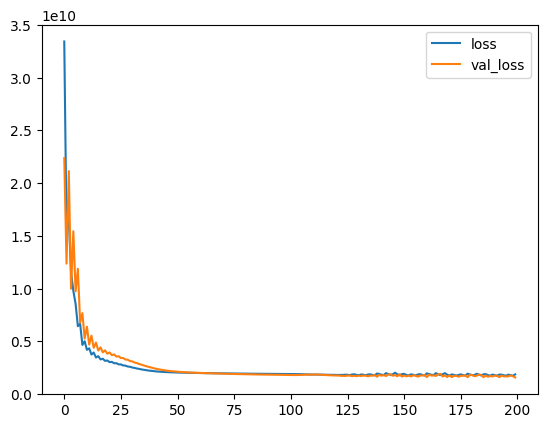

In [41]:
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step
47648.359375


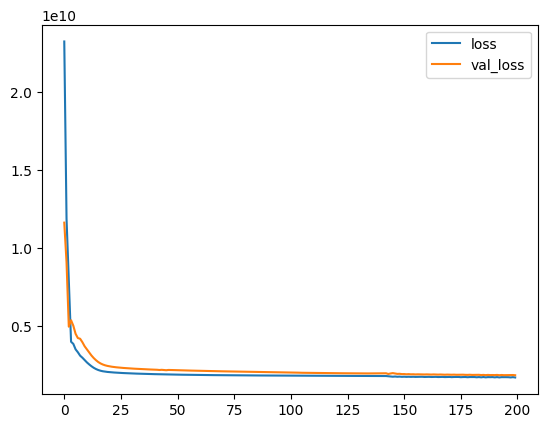

In [53]:
tf.keras.utils.set_random_seed(42)
model_tf2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (p, )), # this defines the number of rows of W1
    tf.keras.layers.Dense(p1, activation = 'relu', use_bias = False), # u1 = X@W1, h1 = relu(u1)
    tf.keras.layers.Dense(1, use_bias = False) #  u2 = h1@W2 (1 is the 2nd dim of y.)
])
model_tf2.compile(
    loss = 'mse',
    optimizer= tf.keras.optimizers.SGD(learning_rate=1e-11, momentum = 0.95, nesterov = True),
    #optimizer = 'RMSprop',
    #optimizer = 'Adam',
    #optimizer = opt,
)

hist = model_tf2.fit(
    X_train,
    y_train,
    batch_size = 100, # this is like in simple_NN(), X_train will only have 110 many rows
    # tensorflow will split our X_train into about 2197/110 \approx 20 portions
    epochs = 200, # 1 epoch means the package will run all 20 portions (go through the whole X_train ONCE)
    verbose = 0,
    validation_split = 0.1,
    #validation_data=(X_test, y_test)
)
print(root_mean_squared_error(model_tf2.predict(X_test), y_test))
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
39738.19140625


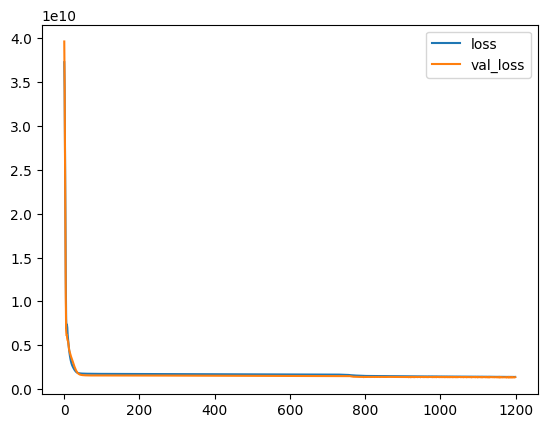

In [52]:
tf.keras.utils.set_random_seed(42)
model_tf3 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (p, )), # this defines the number of rows of W1
    tf.keras.layers.Dense(p1, activation = 'relu', use_bias = False), # u1 = X@W1, h1 = relu(u1)
    tf.keras.layers.Dense(1, use_bias = False) #  u2 = h1@W2 (1 is the 2nd dim of y.)
])

model_tf3.compile(
    loss = 'mse',
    #optimizer= tf.keras.optimizers.SGD(learning_rate=1e-11, momentum = 0.95),
    #optimizer = 'RMSprop',
    optimizer= tf.keras.optimizers.RMSprop(momentum = 0.95,)
    #optimizer = 'Adam',
    #optimizer = opt,
)

hist = model_tf3.fit(
    X_train,
    y_train,
    batch_size = 200, # this is like in simple_NN(), X_train will only have 110 many rows
    # tensorflow will split our X_train into about 2197/110 \approx 20 portions
    epochs = 1200, # 1 epoch means the package will run all 20 portions (go through the whole X_train ONCE)
    verbose = 0,
    validation_split = 0.1,
)
print(root_mean_squared_error(model_tf3.predict(X_test), y_test))
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
201087.15625


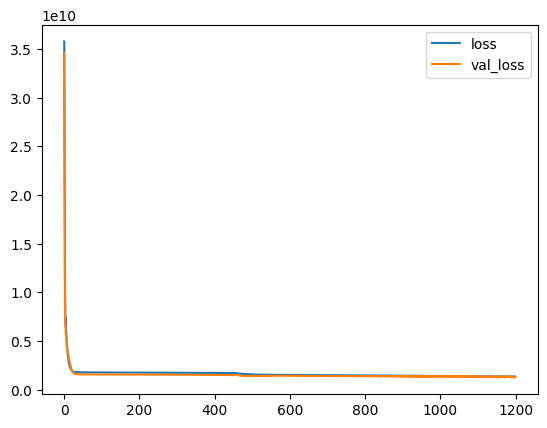

In [47]:
model_tf4 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (p, )), # this defines the number of rows of W1
    tf.keras.layers.Dense(p1, activation = 'relu', use_bias = False), # u1 = X@W1, h1 = relu(u1)
    tf.keras.layers.Dense(1, use_bias = False) #  u2 = h1@W2 (1 is the 2nd dim of y.)
])

model_tf4.compile(
    loss = 'mse',
    #optimizer= tf.keras.optimizers.SGD(learning_rate=1e-11, momentum = 0.95),
    #optimizer = 'RMSprop',
    optimizer = tf.keras.optimizers.Adagrad(),
    #optimizer = opt,
)

model_tf4.fit(
    X_train,
    y_train,
    batch_size = 100, # this is like in simple_NN(), X_train will only have 110 many rows
    # tensorflow will split our X_train into about 2197/110 \approx 20 portions
    epochs = 800, # 1 epoch means the package will run all 20 portions (go through the whole X_train ONCE)
    verbose = 0,
    validation_split = 0.1,
)
print(root_mean_squared_error(model_tf4.predict(X_test), y_test))
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [55]:
x = np.ones([2,3])
x

array([[1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
x[1:3,:]

In [ ]:
733/32